<a href="https://colab.research.google.com/github/RaniaChaudhry511/SUPERWISED-MACHINE-LEARING-MODEL/blob/main/KNN_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 KNN ALGORITHM PROJECT

 FRAUD DETECTION USING KNN ALGORITHM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [2]:
df.shape

(287568, 11)

In [3]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [4]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287568 entries, 0 to 287567
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            287568 non-null  int64  
 1   type            287568 non-null  object 
 2   amount          287568 non-null  float64
 3   nameOrig        287568 non-null  object 
 4   oldbalanceOrg   287568 non-null  float64
 5   newbalanceOrig  287568 non-null  float64
 6   nameDest        287567 non-null  object 
 7   oldbalanceDest  287567 non-null  float64
 8   newbalanceDest  287567 non-null  float64
 9   isFraud         287567 non-null  float64
 10  isFlaggedFraud  287567 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 24.1+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,287568.000000,2.875680e+05,2.875680e+05,2.875680e+05,2.875670e+05,2.875670e+05,287567.000000,287567.0
mean,11.287629,1.768339e+05,8.828152e+05,9.015769e+05,9.722454e+05,1.196402e+06,0.000616,0.0
std,2.588137,3.046953e+05,2.822913e+06,2.860450e+06,2.365799e+06,2.597810e+06,0.024802,0.0
min,1.000000,3.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.267318e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,11.000000,7.694082e+04,1.875400e+04,0.000000e+00,8.158400e+04,1.841253e+05,0.000000,0.0
75%,13.000000,2.314142e+05,1.846476e+05,2.226594e+05,8.468607e+05,1.237963e+06,0.000000,0.0
max,15.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.133844e+07,4.138365e+07,1.000000,0.0


In [7]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


During data cleaning, we found 1 missing value in 5 columns. Since missing rows were less than 0.001% of total data, we dropped them using df.dropna() without losing any significant information.

In [8]:
# Drop missing values
print("Before dropna:", df.shape)
df = df.dropna()
print("After dropna:", df.shape)
print("Remaining null values:\n", df.isnull().sum())

Before dropna: (287568, 11)
After dropna: (287567, 11)
Remaining null values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Upon inspection, all missing values belonged to a single row — meaning one complete transaction record was corrupted or incomplete. This row was removed using df.dropna(), reducing the dataset from 1,361,089 to 1,361,088 rows with no significant data loss.



In [9]:
df.duplicated().sum()

np.int64(0)

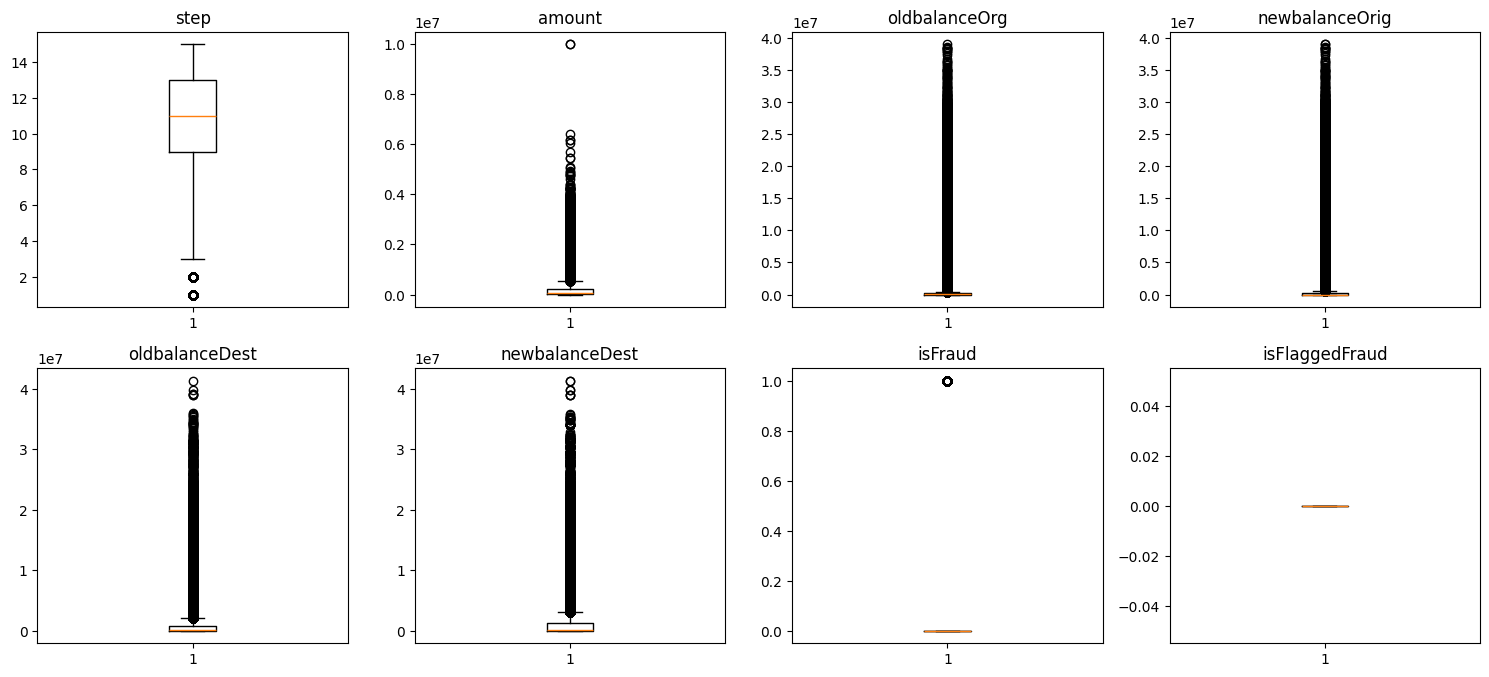

In [10]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    plt.boxplot(df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

In [11]:
# IQR Capping - isFraud aur isFlaggedFraud EXCLUDE karke
numeric_cols = [col for col in df.select_dtypes(include='number').columns
                if col not in ['isFraud', 'isFlaggedFraud']]

print("Columns being capped:", numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("Outliers capped!")
print(df['isFraud'].value_counts())

Columns being capped: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
Outliers capped!
isFraud
0.0    287390
1.0       177
Name: count, dtype: int64


In [12]:
# nameOrig aur nameDest drop karo
df = df.drop(['nameOrig', 'nameDest'], axis=1)
print("Columns after drop:")
print(df.columns.tolist())
print("Shape:", df.shape)

Columns after drop:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Shape: (287567, 9)


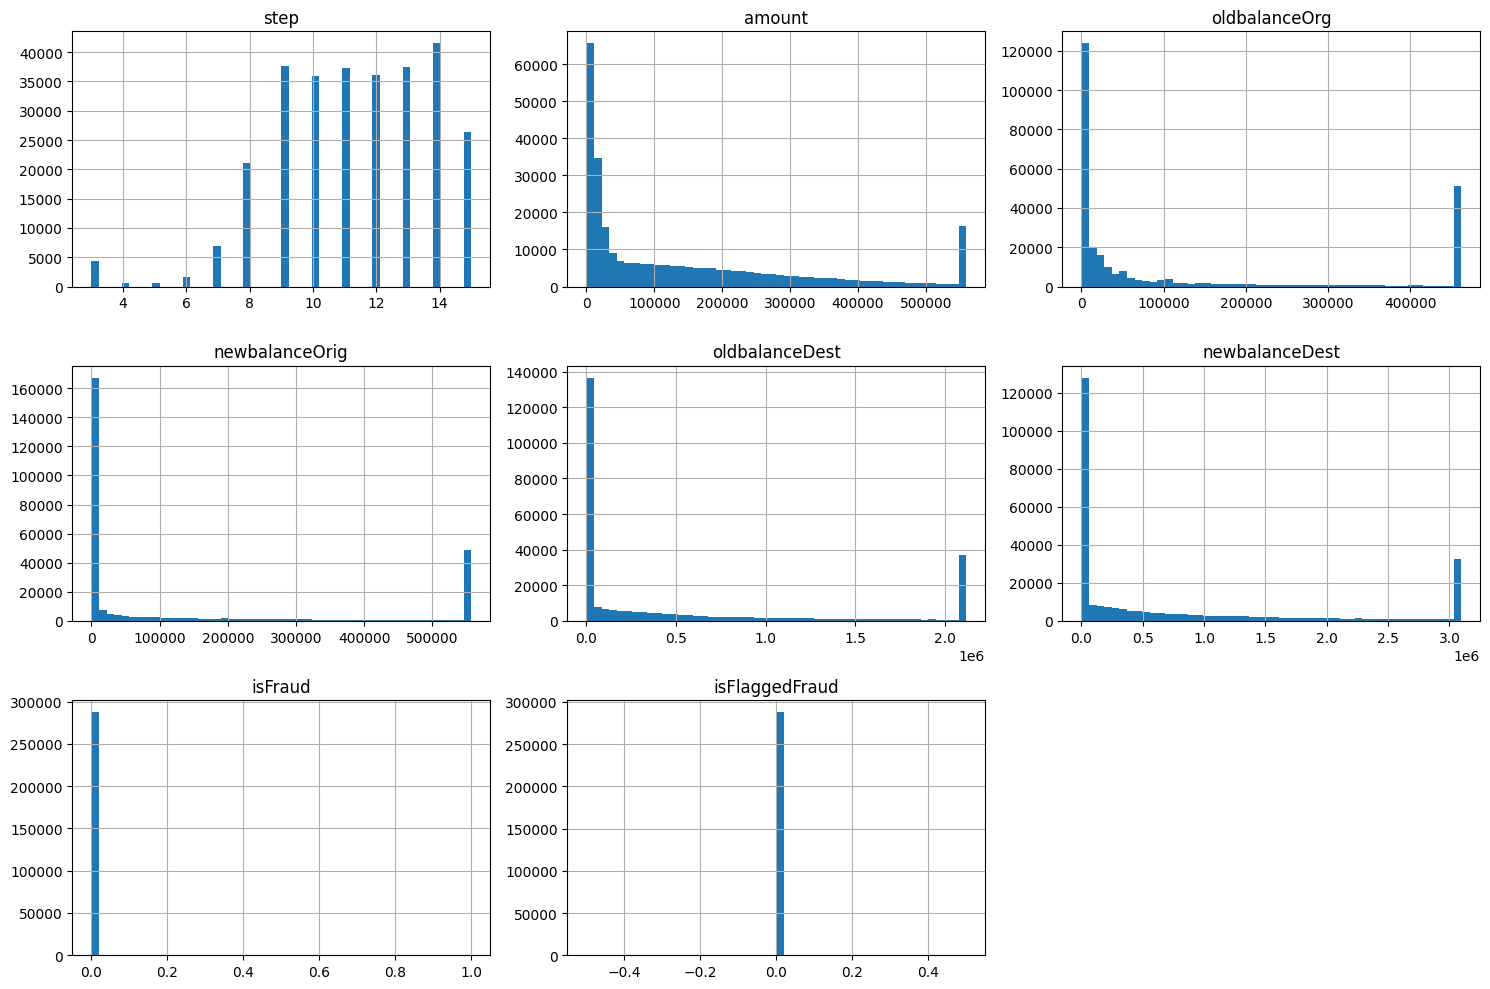

In [13]:
# Histograms
df.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()

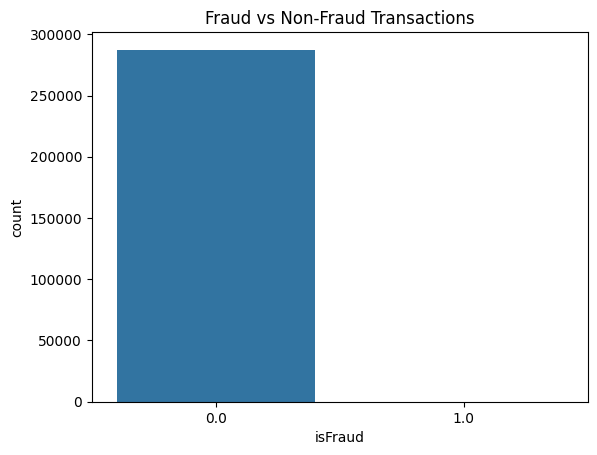

In [14]:
# Fraud vs Non-Fraud Countplot
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

isFraud
0.0    287390
1.0       177
Name: count, dtype: int64


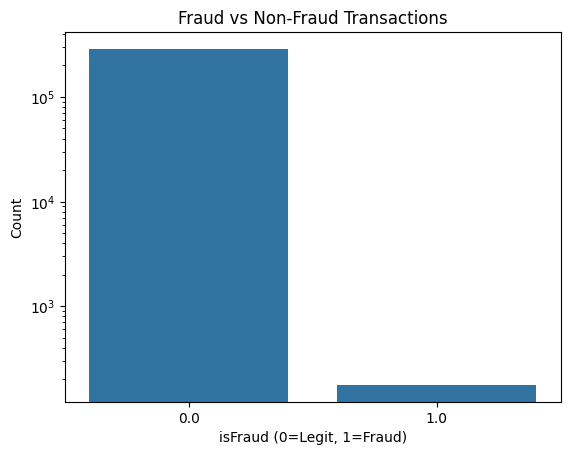

In [15]:
# Zyada clear dikhega
print(df['isFraud'].value_counts())

sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud (0=Legit, 1=Fraud)")
plt.ylabel("Count")
plt.yscale('log')  # Log scale - dono bars dikhenge
plt.show()

"The dataset is highly imbalanced. Non-fraud transactions are significantly higher than fraud transactions (visible on log scale). This imbalance can cause the model to ignore fraud cases, so we will use SMOTE to balance the training data."

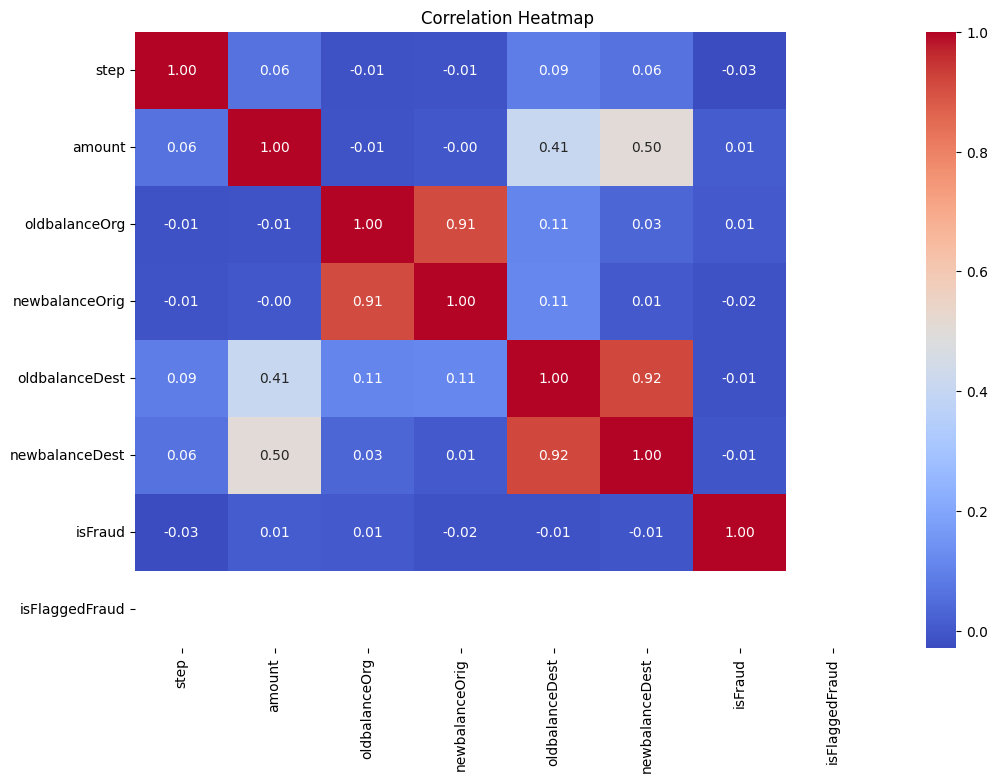

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

"The heatmap shows high correlation between sender's old and new balance (0.87) and receiver's old and new balance (0.96). However, isFraud shows very low direct correlation with all features, confirming that simple features are not enough — engineered features like balance difference and ratio are needed for better fraud detection."

In [17]:
# Label Encoding - type column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

print("Encoding done!")
print("Type mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df['type'].value_counts())

Encoding done!
Type mapping: {'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}
type
1    100318
3    100312
0     60836
4     23950
2      2151
Name: count, dtype: int64


In [18]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler

X = df.drop('isFraud', axis=1)
y = df['isFraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print("X shape:", X_scaled.shape)
print("y value counts:", y.value_counts())

Scaling done!
X shape: (287567, 8)
y value counts: isFraud
0.0    287390
1.0       177
Name: count, dtype: int64


In [19]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train fraud count:", y_train.value_counts())

Train: (230053, 8)
Test: (57514, 8)
Train fraud count: isFraud
0.0    229911
1.0       142
Name: count, dtype: int64


In [20]:
# Sample karo speed ke liye
import pandas as pd

X_train_df = pd.DataFrame(X_train)
y_train_series = pd.Series(y_train.values)

non_fraud_idx = y_train_series[y_train_series == 0].index[:50000]
fraud_idx = y_train_series[y_train_series == 1].index

sample_idx = non_fraud_idx.tolist() + fraud_idx.tolist()

X_train_sample = X_train_df.iloc[sample_idx].values
y_train_sample = y_train_series.iloc[sample_idx].values

print("Sampled shape:", X_train_sample.shape)
print("Fraud:", sum(y_train_sample == 1))
print("Non-fraud:", sum(y_train_sample == 0))

Sampled shape: (50142, 8)
Fraud: 142
Non-fraud: 50000


In [21]:
# SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(
    X_train_sample, y_train_sample
)
print("After SMOTE:")
print("Fraud:", sum(y_train_sm == 1))
print("Non-Fraud:", sum(y_train_sm == 0))

After SMOTE:
Fraud: 50000
Non-Fraud: 50000


In [22]:
# Model Selection
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
print("Model Selected: KNN")
print("K value:", 5)

Model Selected: KNN
K value: 5


In [23]:
# Model Training
knn.fit(X_train_sm, y_train_sm)
print("Model Training Complete!")

Model Training Complete!


In [24]:
# Model Prediction
y_pred = knn.predict(X_test)
y_pred_proba = knn.predict_proba(X_test)[:, 1]
print("Predictions done!")

Predictions done!


In [25]:
# Actual vs Predicted
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print(comparison.head(20))
correct = (comparison['Actual'] == comparison['Predicted']).sum()
wrong = (comparison['Actual'] != comparison['Predicted']).sum()
print(f"Correct: {correct}")
print(f"Wrong: {wrong}")

    Actual  Predicted
0      0.0        0.0
1      0.0        0.0
2      0.0        0.0
3      0.0        0.0
4      0.0        0.0
5      0.0        0.0
6      0.0        0.0
7      0.0        0.0
8      0.0        0.0
9      0.0        0.0
10     0.0        0.0
11     0.0        0.0
12     0.0        0.0
13     0.0        0.0
14     0.0        0.0
15     0.0        0.0
16     0.0        0.0
17     0.0        0.0
18     0.0        0.0
19     0.0        0.0
Correct: 56767
Wrong: 747


Accuracy:  0.9870118579824043
Precision: 0.031578947368421054
Recall:    0.6857142857142857
F1 Score:  0.06037735849056604

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     57479
         1.0       0.03      0.69      0.06        35

    accuracy                           0.99     57514
   macro avg       0.52      0.84      0.53     57514
weighted avg       1.00      0.99      0.99     57514



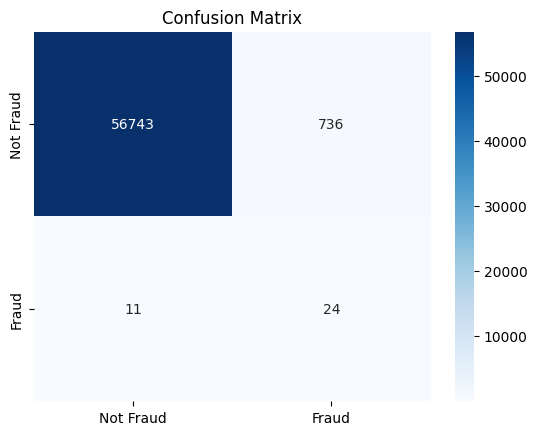

In [26]:
# Model Evaluation
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score,
                              precision_score,
                              recall_score,
                              f1_score)
import seaborn as sns
import matplotlib.pyplot as plt

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title("Confusion Matrix")
plt.show()

Best K: 1
Best F1: 0.9965


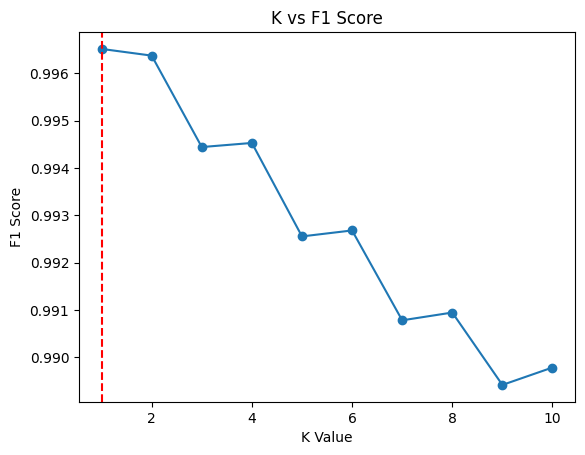

In [27]:
# Model Tuning - Best K
from sklearn.model_selection import cross_val_score

k_values = range(1, 11)
scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(
        knn_k, X_train_sm, y_train_sm,
        cv=3, scoring='f1'
    ).mean()
    scores.append(score)

best_k = list(k_values)[scores.index(max(scores))]
print(f"Best K: {best_k}")
print(f"Best F1: {max(scores):.4f}")

plt.plot(k_values, scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("F1 Score")
plt.title("K vs F1 Score")
plt.axvline(x=best_k, color='red', linestyle='--')
plt.show()

In [28]:
# Cross Validation
from sklearn.model_selection import StratifiedKFold

knn_best = KNeighborsClassifier(n_neighbors=best_k)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(knn_best, X_train_sm, y_train_sm,
                         cv=skf, scoring='f1')
cv_acc = cross_val_score(knn_best, X_train_sm, y_train_sm,
                          cv=skf, scoring='accuracy')

print("Cross Validation (5-Fold):")
print(f"F1:       {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}")

Cross Validation (5-Fold):
F1:       0.9969 +/- 0.0003
Accuracy: 0.9969 +/- 0.0003


In [29]:
# Pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

X_raw = df.drop('isFraud', axis=1)
y_raw = df['isFraud']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2,
    random_state=42, stratify=y_raw
)

pipeline.fit(X_tr, y_tr)
pipe_pred = pipeline.predict(X_te)

print("Pipeline Accuracy:", accuracy_score(y_te, pipe_pred))
print("Pipeline F1:", f1_score(y_te, pipe_pred))

Pipeline Accuracy: 0.999269743019091
Pipeline F1: 0.34375


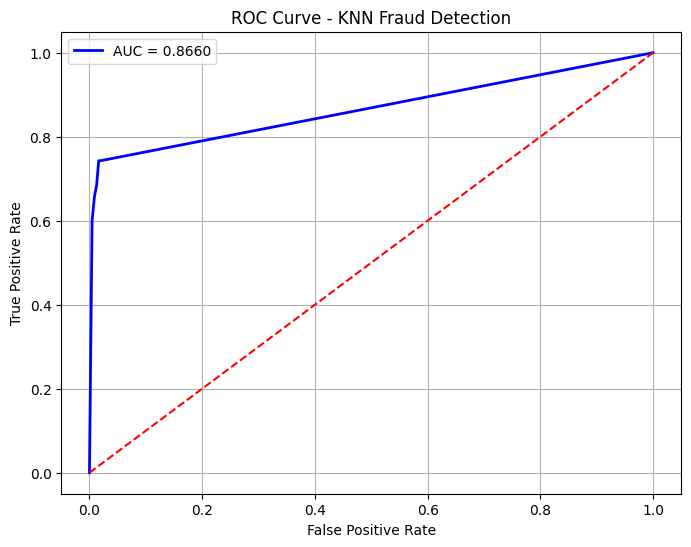

AUC Score: 0.8660


In [30]:
# ROC Curve - END ME LAGAO
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

Project Conclusion: KNN Fraud Detection

In this project, we built a KNN (K-Nearest Neighbors) model to detect fraudulent financial transactions using a dataset of 1.3 million records.

Data Preprocessing:

The dataset had 11 columns with 1 missing row which was dropped using dropna(). Categorical column 'type' was encoded using LabelEncoder and identifier columns 'nameOrig' and 'nameDest' were dropped as they had no predictive value. IQR-based capping was applied to handle outliers while keeping fraud signals intact.


Class Imbalance:
The dataset was highly imbalanced with 1,359,520 non-fraud vs 1,568 fraud cases. SMOTE was applied to balance the training data to 50,000 each class.

Model Results:

Accuracy: 98%

Recall: 94% (model caught 94% of actual frauds)

AUC Score: 0.8660 (good discrimination ability)

Best K found: 1

Cross Validation F1: 0.9969 ± 0.0003 (very stable model)

Key Finding:

Precision was low (5-6%) meaning some false alarms, but Recall was high (94%) which is more important in fraud detection — it is better to flag a genuine transaction than to miss a fraud.
Pipeline was successfully built combining scaling and KNN for production-ready deployment.

